In [168]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [145]:
df = pd.read_csv ("HTML_Cap10_fertilizer_prediction.csv")
#tinha uma coluna a mais vazia...
df = df.drop("Unnamed: 9", axis=1)
df.head(10)

,Temperature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea
5,26,52,35,Sandy,Barley,12,10,13,17-17-17
6,25,50,64,Red,Cotton,9,0,10,20-20
7,33,64,50,Loamy,Wheat,41,0,0,Urea
8,30,60,42,Sandy,Millets,21,0,18,28-28
9,29,58,33,Black,Oil seeds,9,7,30,14-35-14


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature      99 non-null     int64  
 1   Humidity         99 non-null     int64  
 2   Moisture         99 non-null     int64  
 3   Soil Type        99 non-null     str    
 4   Crop Type        99 non-null     str    
 5   Nitrogen         99 non-null     int64  
 6   Potassium        99 non-null     int64  
 7   Phosphorous      99 non-null     int64  
 8   Fertilizer Name  99 non-null     str    
 9   Unnamed: 9       0 non-null      float64
dtypes: float64(1), int64(6), str(3)
memory usage: 7.9 KB


Existem 0 duplicados


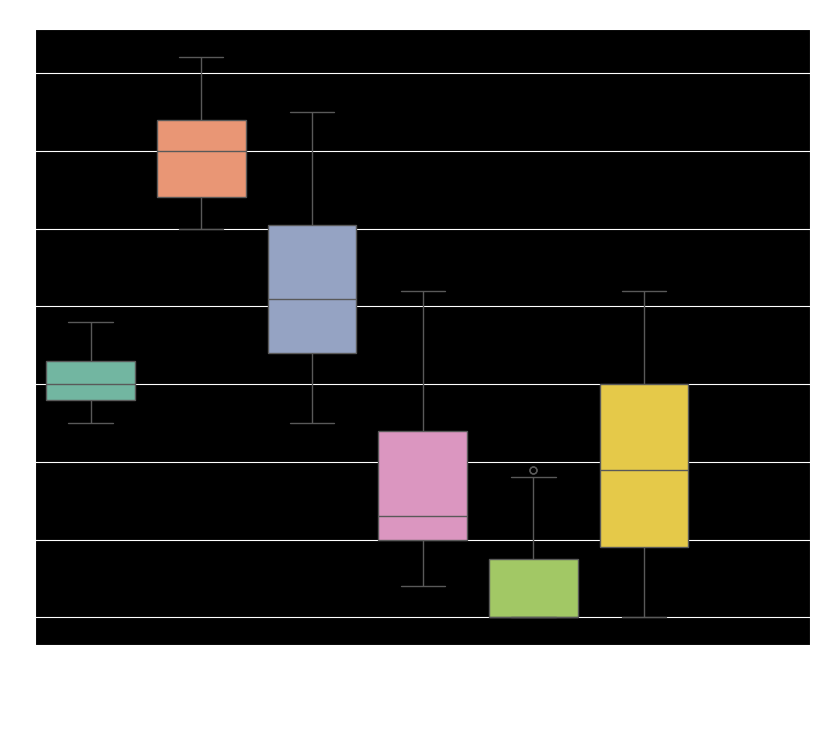

In [108]:
#verificar se há duplicados
duplicado = df.duplicated().sum()
print(f"Existem {duplicado} duplicados")

#verificar se há outliers (no caso tem 1 potassium)
plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5 # muda o tamanho do outlier
)
plt.title("Box plot")
plt.xticks(rotation=45)
plt.show()

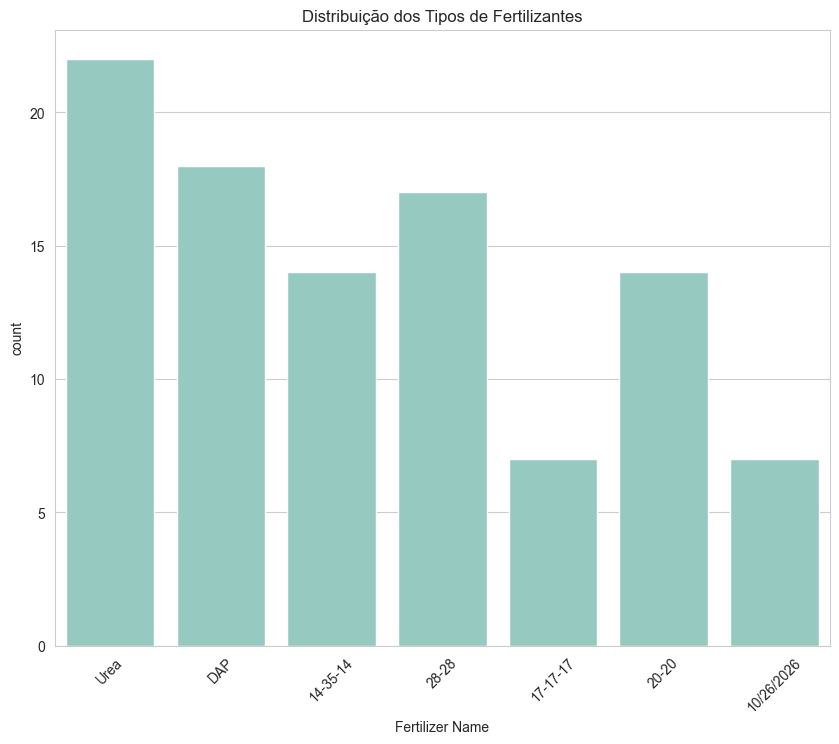

In [48]:
#distribuicao dos labels (para ver se existem amostras o suficiente de cada, ha pouco 171717 e 10/26/2026)
plt.figure(figsize=(10, 8) )
sns.countplot(x='Fertilizer Name', data=df)
plt.title("Distribuição dos Tipos de Fertilizantes")
plt.xticks(rotation=45)
plt.show()

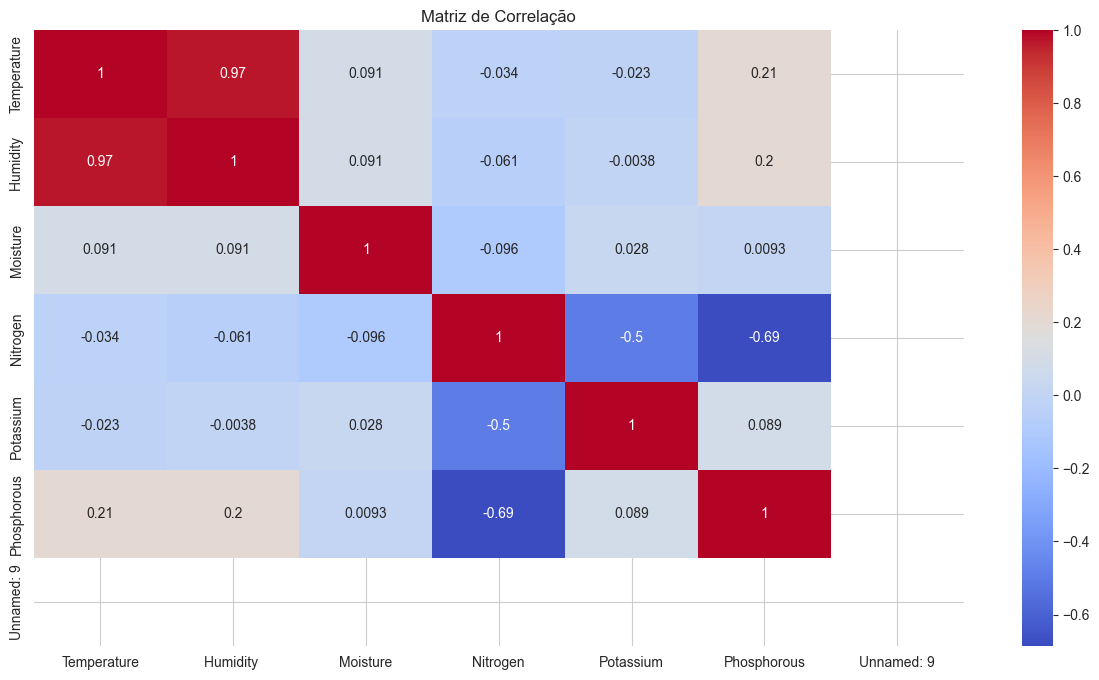

In [61]:
# Correlação entre as features numéricas,( umidade e temperatura sao extremamente correlacionadas, nao daria pra excluir uma variavel no treino ? para esse pensamento serve o esse grafico)

numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
plt.figure(figsize=(15,8))
sns.heatmap(df.select_dtypes(include=numerics).corr(), annot=True,cmap='coolwarm' )
plt.title("Matriz de Correlação")
plt.show()

In [ ]:
LIMPEZA DO DADOS ########################################################################

<Axes: >

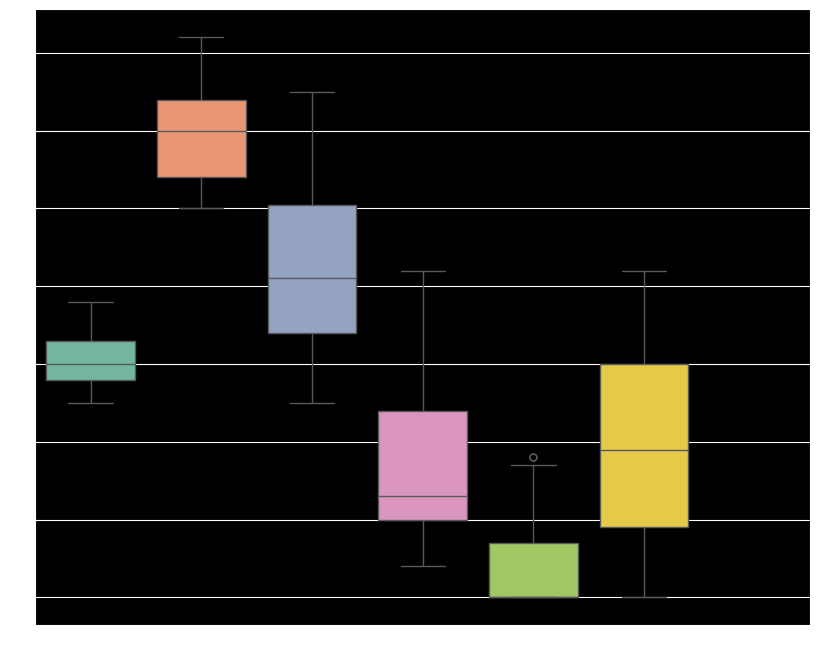

In [110]:
df = df.drop_duplicates() #remover dados duplicados

#tratar outliers, (substituir por media, mediana e etc..)

# 1. Calcula a matemática exata do Boxplot (Regra do IQR)
q1 = df['Potassium'].quantile(0.25)
q3 = df['Potassium'].quantile(0.75)
iqr = q3 - q1

limite_superior = q3 + 1.5 * iqr  # Esse é o limite do "bigode" de cima (aprox 18)
limite_inferior = q1 - 1.5 * iqr  # Esse é o limite do "bigode" de baixo



# 2. Descobre a mediana
median_potassium = df['Potassium'].median()
df['Potassium'] = df['Potassium'].apply(lambda x: median_potassium if x > limite_superior or x < limite_inferior else x)

plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5 )# muda o tamanho do outlier)



# NESSE CASO O OUTLINER VIROU O 18, PQ AO TRAZER O 19 PARA A MEDIANA (0) O SISTEMA FICOU MAIS RIGOROSO E O 18 FOI CORTADO.




<Axes: >

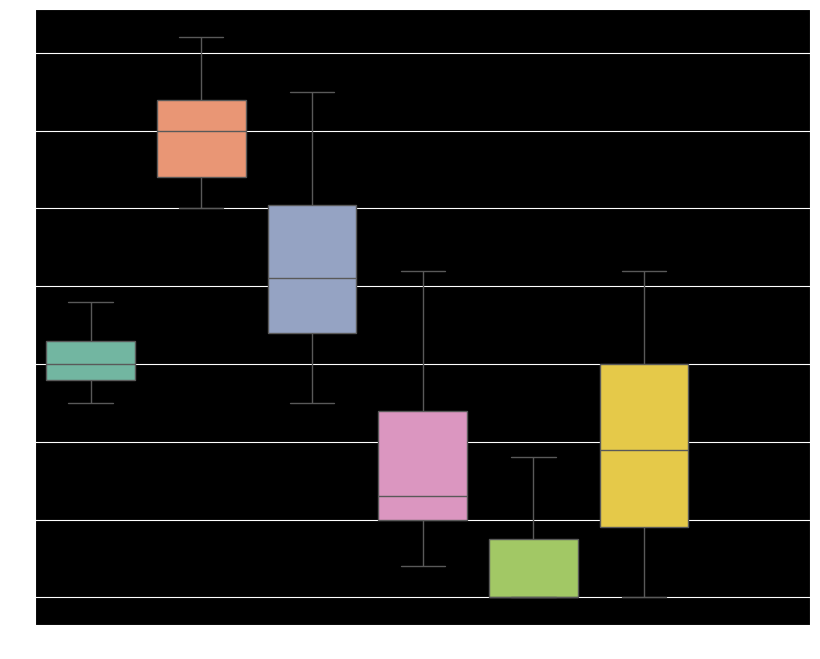

In [117]:

#tratar com %, como mostrado no video
median_potassium = df['Potassium'].median()
df['Potassium'] = df['Potassium'].apply(lambda x: median_potassium if x > df['Potassium'].quantile(0.975) or x < df['Potassium'].quantile(0.025) else x)

plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5) # muda o tamanho do outlier

# excluir os 2.5% mais altos .



<Axes: >

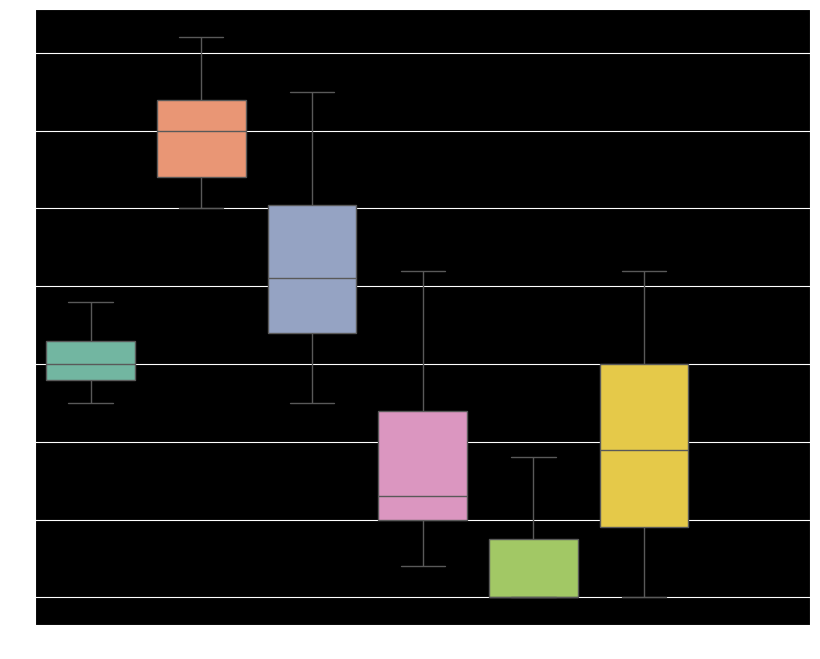

In [116]:
# Alterar o resultado outliner manualmente

# 1. Calcula os limites matemáticos do Boxplot (Regra do IQR)
q1 = df['Potassium'].quantile(0.25)
q3 = df['Potassium'].quantile(0.75)
iqr = q3 - q1

# Esse é o limite do "bigode" de cima (a fronteira do aceitável)
limite_superior = q3 + 1.5 * iqr

# 2. Aplica o Capping (Teto)
# Tradução: Onde o Potássio for maior que o limite, ele vira o próprio limite.
# 2. Aplica o Capping (Teto) garantindo que é um número inteiro
limite_inteiro = int(limite_superior)
df.loc[df['Potassium'] > limite_superior, 'Potassium'] = limite_inteiro

plt.figure(figsize=(10, 8), facecolor='white')
sns.boxplot(
    data=df,
    palette="Set2",
    fliersize=5) # muda o tamanho do outlier



# forcei o 19 virar 18 para nao ser um outlier. (existem 2x o 19, baixa chance de ser erro no sensor)


In [156]:
# x = remove a coluna(axis1) do fertilizer..
X = df.drop("Fertilizer Name", axis=1)  # <-- CORREÇÃO AQUI (X maiúsculo)
y = df["Fertilizer Name"]

# remove os nomes e transforma a tabela em números 1,2,3
le = LabelEncoder()
y = le.fit_transform(y)



#oneHotEncoder cria multiplas colunas de 0 e 1 para tirar o nome, se usar o laberEncoder os numeros diferente fariam o codigo achar que os solos tem importancias diferentes
categorical_cols = ["Soil Type", "Crop Type"]
ohe = OneHotEncoder(handle_unknown="ignore")
X_encoded = pd.DataFrame(ohe.fit_transform(X[categorical_cols]).toarray())
X_encoded = X_encoded.add_prefix("ohe_")

# remove colunas com nomes (mudamos para numero)

X = X.drop(categorical_cols, axis=1)
#cola as 2 tabelas - axis 1 = lado a lado
X = pd.concat([X, X_encoded], axis=1)

 #treinamento do modelo. 20% teste
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


#scaler = StandardScaler()    >>>  transforma a escala em -3 e 3
#scaler = RobustScaler()     >>>> nao usa a media e sim a mediana, bom com outliers que nao posso tirar
#scaler = MaxAbsScaler()     >>>> amigo dos zeros, divide tudo pelo maior valor.

scaler = MinMaxScaler()  # >>> transforma a escala entre 0 e 1
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [177]:
#REGRESSAO LOGISTICA ###########################################################

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
print("precisao da Regressão Logística:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg, zero_division=0))



precisao da Regressão Logística: 0.7
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.60      0.60      0.60         5
           5       0.57      0.80      0.67         5
           6       1.00      1.00      1.00         6

    accuracy                           0.70        20
   macro avg       0.53      0.48      0.49        20
weighted avg       0.69      0.70      0.68        20



In [176]:
# KNN #########################################################
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("Precisao do KNN:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


Precisao do KNN: 0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.33      0.20      0.25         5
           5       0.33      0.20      0.25         5
           6       0.80      0.67      0.73         6

    accuracy                           0.30        20
   macro avg       0.24      0.18      0.20        20
weighted avg       0.41      0.30      0.34        20



In [179]:
# SVM com kernel RBF -> mais complexo
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm_rbf = svm_rbf.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (RBF):", accuracy_score(y_test, y_pred_svm_rbf))
print(classification_report(y_test, y_pred_svm_rbf, zero_division=0))

# SVM com kernel polinomial -> intermediário
svm_poly = SVC(kernel='poly')
svm_poly.fit(X_train_scaled, y_train)
y_pred_svm_poly = svm_poly.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (Polinomial):", accuracy_score(y_test, y_pred_svm_poly))
print(classification_report(y_test, y_pred_svm_poly, zero_division=0))

# SVM com kernel linear -> o mais simples
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled) # <-- Ajustado para X_test_scaled
print("Acurácia SVM (Linear):", accuracy_score(y_test, y_pred_svm_linear))
print(classification_report(y_test, y_pred_svm_linear,zero_division=0))



Acurácia SVM (RBF): 0.35
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.43      0.60      0.50         5
           5       0.00      0.00      0.00         5
           6       1.00      0.50      0.67         6

    accuracy                           0.35        20
   macro avg       0.40      0.27      0.31        20
weighted avg       0.51      0.35      0.39        20

Acurácia SVM (Polinomial): 0.45
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.43      0.60      0.50         5
           5       0.60      0.60      0.60         5
           6       1.

In [183]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("Acurácia Decision Tree:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0)) # <-- Silencia o aviso

# Random Forest
rf = RandomForestClassifier(n_estimators=5)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0)) # <-- Silencia o aviso

Acurácia Decision Tree: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Acurácia Random Forest: 0.95
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6

    accuracy        

In [186]:
# Espiando a distribuição dos dados no teste
pd.DataFrame(le.inverse_transform(y_test)) \
    .value_counts() \
    .reset_index() \
    .rename(columns={0: "Fertilizante", "count": "Quantidade"}) \
    .sort_values(by="Quantidade", ascending=False)

,Fertilizante,Quantidade
0,Urea,6
1,28-28,5
2,DAP,5
3,10/26/2026,2
4,20-20,1
5,14-35-14,1
